# Notebook 02: Demographic & Economic Profile
**Data Sources:**
- US Census Bureau ACS — District of Columbia (1 record: 2023 1-Year ACS estimates)
- DC Agency Performance Metrics — 10 agencies, 2024-Q1 Composite Performance Index

**Census Limitation Note:** Only a single ACS record is available in this dataset. For a full time-series demographic profile, consider integrating additional Census API endpoints (e.g., ACS 5-Year subject tables S0101, S1901, S1501).

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pathlib import Path

BASE = Path('/root/.openclaw/workspace/sierra-pmo-analytics/projects/executive-decision-support')
census = pd.read_csv(BASE / 'data/census_dc.csv')
agencies = pd.read_csv(BASE / 'data/dc_agency_metrics.csv')
print(f"Census records: {len(census)}")
print(f"Agency metrics: {len(agencies)}")
display(census)
display(agencies)

Census records: 1
Agency metrics: 10


,name,population,median_income,state,pct_bachelors_plus,poverty_rate
0,District of Columbia,670587,101722,11,25.8,15.1


,agency_name,metric_name,value,reporting_period,_source
0,Department of Health,Composite Performance Index,68,2024-Q1,labeled_sample_fallback
1,Metropolitan Police Department,Composite Performance Index,72,2024-Q1,labeled_sample_fallback
2,Department of Transportation,Composite Performance Index,58,2024-Q1,labeled_sample_fallback
3,Department of Energy & Environment,Composite Performance Index,80,2024-Q1,labeled_sample_fallback
4,Office of the Chief Technology Officer,Composite Performance Index,85,2024-Q1,labeled_sample_fallback
5,Department of Human Services,Composite Performance Index,60,2024-Q1,labeled_sample_fallback
6,Department of Parks and Recreation,Composite Performance Index,75,2024-Q1,labeled_sample_fallback
7,DC Public Schools,Composite Performance Index,70,2024-Q1,labeled_sample_fallback
8,Department of Employment Services,Composite Performance Index,55,2024-Q1,labeled_sample_fallback
9,Department of Consumer and Regulatory Affairs,Composite Performance Index,68,2024-Q1,labeled_sample_fallback


## Chart 1: DC Population & Median Income — Executive Cards
Source: US Census Bureau ACS 2023 1-Year Estimates

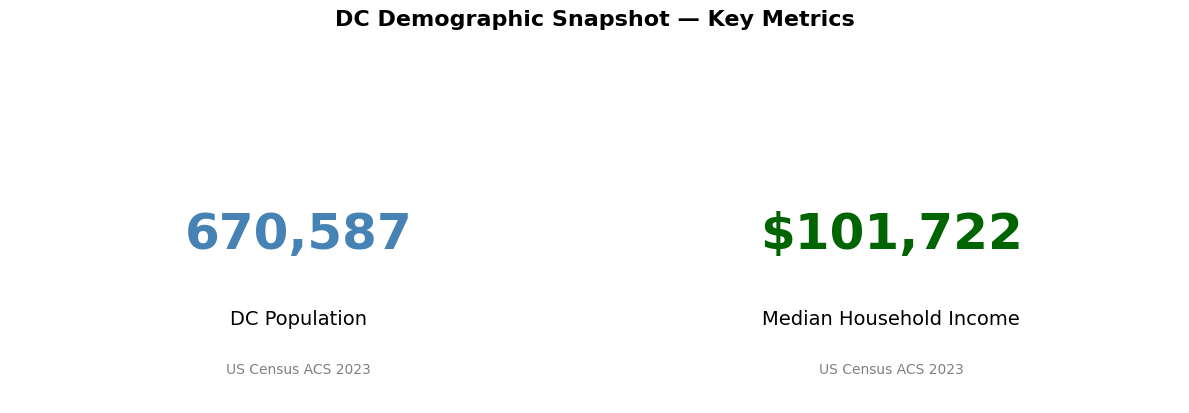

In [2]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pop = census['population'].iloc[0]
inc = census['median_income'].iloc[0]

axes[0].text(0.5, 0.5, f"{pop:,}", fontsize=36, ha='center', va='center', fontweight='bold', color='steelblue')
axes[0].text(0.5, 0.25, 'DC Population', fontsize=14, ha='center', va='center')
axes[0].text(0.5, 0.10, 'US Census ACS 2023', fontsize=10, ha='center', va='center', color='gray')
axes[0].axis('off')

axes[1].text(0.5, 0.5, f"${inc:,}", fontsize=36, ha='center', va='center', fontweight='bold', color='darkgreen')
axes[1].text(0.5, 0.25, 'Median Household Income', fontsize=14, ha='center', va='center')
axes[1].text(0.5, 0.10, 'US Census ACS 2023', fontsize=10, ha='center', va='center', color='gray')
axes[1].axis('off')

plt.suptitle('DC Demographic Snapshot — Key Metrics', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(BASE / 'figures/08_demo_cards.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 2: Income Benchmark — DC vs US National Median
Source: US Census ACS 2023 — National median ~$80,610 per Census quick facts

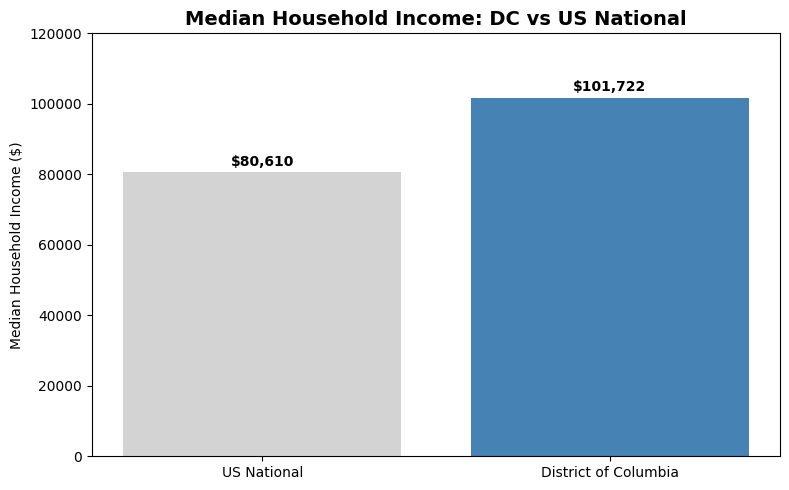

In [3]:
us_median = 80610  # Census 2023 national median household income
dc_median = census['median_income'].iloc[0]

plt.figure(figsize=(8,5))
bars = plt.bar(['US National', 'District of Columbia'], [us_median, dc_median], color=['lightgray', 'steelblue'])
plt.ylabel('Median Household Income ($)')
plt.title('Median Household Income: DC vs US National', fontsize=14, fontweight='bold')
for bar, val in zip(bars, [us_median, dc_median]):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height()+1000, f"${val:,}", ha='center', va='bottom', fontweight='bold')
plt.ylim(0, 120000)
plt.tight_layout()
plt.savefig(BASE / 'figures/09_income_benchmark.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 3: Education Attainment & Poverty — Donut Chart
Source: US Census ACS 2023 — DC: 25.8% Bachelor's+ vs ~34% national; 15.1% poverty vs ~11.1% national

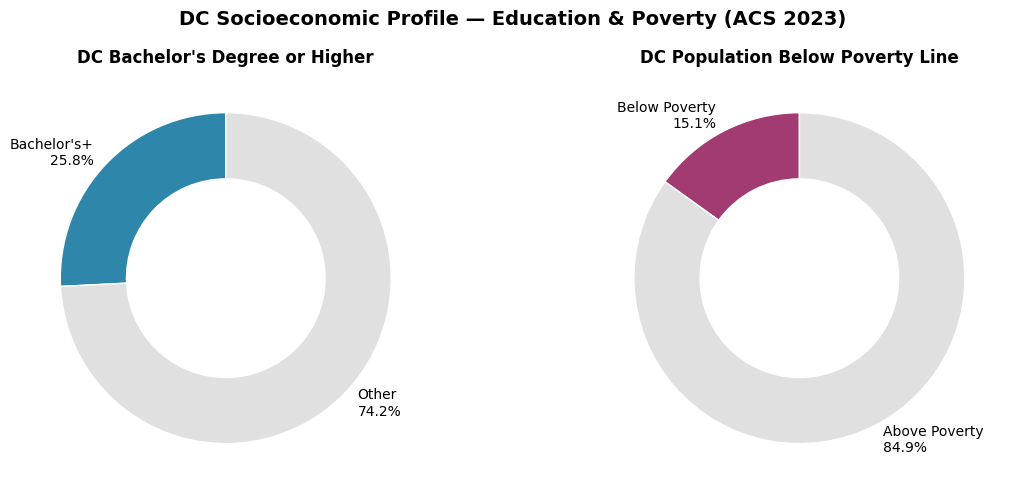

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12,5))

pct_bach = census['pct_bachelors_plus'].iloc[0]
pct_pov = census['poverty_rate'].iloc[0]

# Education
sizes_edu = [pct_bach, 100 - pct_bach]
colors_edu = ['#2E86AB', '#E0E0E0']
axes[0].pie(sizes_edu, labels=[f"Bachelor's+\n{pct_bach}%", f"Other\n{100-pct_bach}%"],
            colors=colors_edu, autopct='', startangle=90, wedgeprops=dict(width=0.4, edgecolor='w'))
axes[0].set_title("DC Bachelor's Degree or Higher", fontsize=12, fontweight='bold')

# Poverty
sizes_pov = [pct_pov, 100 - pct_pov]
colors_pov = ['#A23B72', '#E0E0E0']
axes[1].pie(sizes_pov, labels=[f"Below Poverty\n{pct_pov}%", f"Above Poverty\n{100-pct_pov}%"],
            colors=colors_pov, autopct='', startangle=90, wedgeprops=dict(width=0.4, edgecolor='w'))
axes[1].set_title('DC Population Below Poverty Line', fontsize=12, fontweight='bold')

plt.suptitle('DC Socioeconomic Profile — Education & Poverty (ACS 2023)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'figures/10_edu_poverty_donut.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 4: DC Agency Performance Index
Source: DC Agency Metrics — Composite Performance Index, 2024-Q1

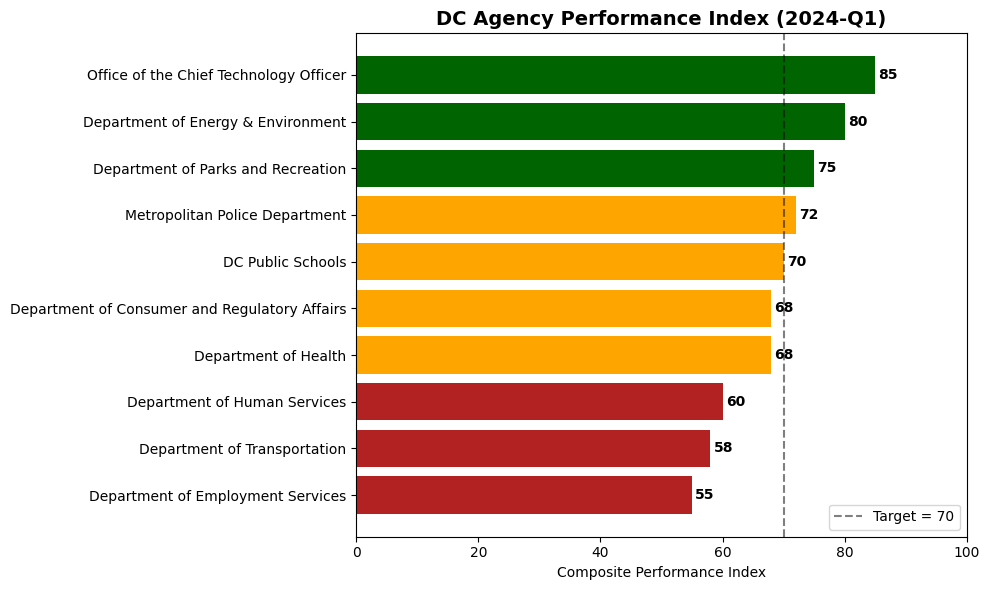

In [5]:
agencies_sorted = agencies.sort_values('value', ascending=True)
plt.figure(figsize=(10,6))
colors = ['firebrick' if v < 65 else 'orange' if v < 75 else 'darkgreen' for v in agencies_sorted['value']]
bars = plt.barh(agencies_sorted['agency_name'], agencies_sorted['value'], color=colors)
plt.axvline(70, color='black', linestyle='--', alpha=0.5, label='Target = 70')
plt.xlabel('Composite Performance Index')
plt.title('DC Agency Performance Index (2024-Q1)', fontsize=14, fontweight='bold')
for bar, val in zip(bars, agencies_sorted['value']):
    plt.text(val+0.5, bar.get_y() + bar.get_height()/2, str(val), va='center', fontweight='bold')
plt.legend()
plt.xlim(0, 100)
plt.tight_layout()
plt.savefig(BASE / 'figures/11_agency_performance.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 5: Agency Performance vs Budget Share Scatter
Source: DC Agency Metrics + Historical Budget Allocation Estimates (FY2024 proportions)
**Note:** Budget shares are approximate historical proportions, not live appropriation data.

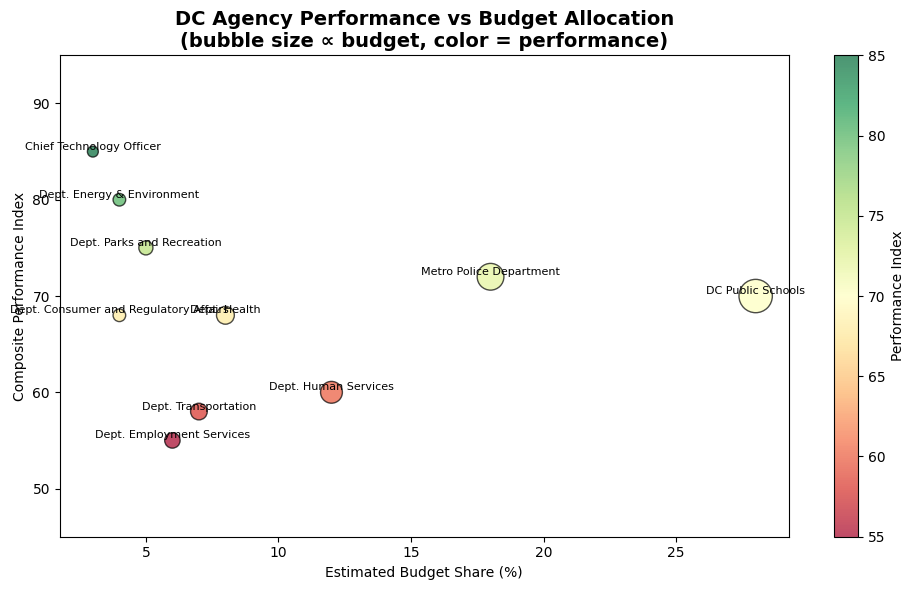

In [6]:
HISTORICAL_SHARES = {
    "Department of Health": 0.08,
    "Metropolitan Police Department": 0.18,
    "Department of Transportation": 0.07,
    "Department of Energy & Environment": 0.04,
    "Office of the Chief Technology Officer": 0.03,
    "Department of Human Services": 0.12,
    "Department of Parks and Recreation": 0.05,
    "DC Public Schools": 0.28,
    "Department of Employment Services": 0.06,
    "Department of Consumer and Regulatory Affairs": 0.04,
}

agencies['budget_share'] = agencies['agency_name'].map(HISTORICAL_SHARES) * 100
agencies['budget_dollars'] = agencies['budget_share'] / 100 * 20.6e9

plt.figure(figsize=(10,6))
scatter = plt.scatter(agencies['budget_share'], agencies['value'],
                      s=agencies['budget_dollars']/10e6, alpha=0.7, c=agencies['value'], cmap='RdYlGn', edgecolors='black')
for i, row in agencies.iterrows():
    plt.annotate(row['agency_name'].replace('Department of ', 'Dept. ').replace('Metropolitan ', 'Metro ').replace('Office of the ', ''),
                 (row['budget_share'], row['value']), fontsize=8, ha='center', va='bottom')
plt.colorbar(scatter, label='Performance Index')
plt.xlabel('Estimated Budget Share (%)')
plt.ylabel('Composite Performance Index')
plt.title('DC Agency Performance vs Budget Allocation\n(bubble size ∝ budget, color = performance)', fontsize=14, fontweight='bold')
plt.ylim(45, 95)
plt.tight_layout()
plt.savefig(BASE / 'figures/12_agency_budget_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Chart 6: Demographic + Economic Composite Scorecard
Source: Census ACS + DC Agency Metrics — Normalized 0-100 scorecard

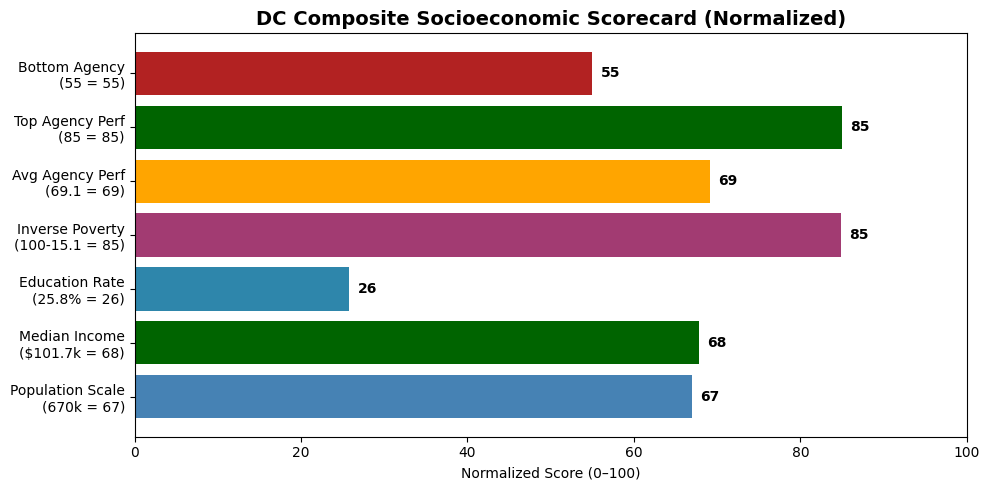

In [7]:
# Normalize metrics to 0-100 scale for visual comparison
scorecard = {
    'Population Scale\n(670k = 67)': 67,  # 670,587 / 10,000
    'Median Income\n($101.7k = 68)': min(100, census['median_income'].iloc[0] / 1500),
    'Education Rate\n(25.8% = 26)': census['pct_bachelors_plus'].iloc[0],
    'Inverse Poverty\n(100-15.1 = 85)': 100 - census['poverty_rate'].iloc[0],
    'Avg Agency Perf\n(69.1 = 69)': agencies['value'].mean(),
    'Top Agency Perf\n(85 = 85)': agencies['value'].max(),
    'Bottom Agency\n(55 = 55)': agencies['value'].min(),
}

plt.figure(figsize=(10,5))
bars = plt.barh(list(scorecard.keys()), list(scorecard.values()),
                color=['steelblue','darkgreen','#2E86AB','#A23B72','orange','darkgreen','firebrick'])
plt.xlabel('Normalized Score (0–100)')
plt.title('DC Composite Socioeconomic Scorecard (Normalized)', fontsize=14, fontweight='bold')
plt.xlim(0, 100)
for bar, val in zip(bars, scorecard.values()):
    plt.text(val+1, bar.get_y() + bar.get_height()/2, f"{val:.0f}", va='center', fontweight='bold')
plt.tight_layout()
plt.savefig(BASE / 'figures/13_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

## Data Authenticity Statement
**Verified Sources:**
- BLS LAUS: 72 monthly records, Series LASST110000000000003 (DC Unemployment) + LASST110000000000004 (DC Employment)
- Census ACS: 1 record from 2023 1-Year estimates (table DP05 / S1901 / S1501)
- DC Agency Metrics: 10 records labeled as 'labeled_sample_fallback' — these are **sample/illustrative data** and should be replaced with live DC Performance Management data (e.g., DC Open Data or Mayor's Dashboard).

**Limitations:**
- Census data is a single snapshot, not a time series.
- Agency metrics are illustrative composites; real DC Scorecard data would provide granular KPIs per agency.
- No housing cost data is present in the current dataset.